## Introduksjon

Vi er gruppe 13 i IS-218. Dette er vår løsning av Oppgave 2: GIScience og Romlig Analyse. Vi valgte temaet: Sivil beredskap og evakuering. Vi landet på valget ved at vi ønsket å bruke data om tilfluktsrom som bakgrunn av verdensbildet i dag. Dermed har vi hentet data om veier, tilfluktsrom og sivilt beredskap.

Gruppemedlemmene våre består av:

**Emil André Johansen Haraldsø**

**Herman Berge Hansen**

**Herman Lonkemoen Haraldsen**

**Preben Jensen**

**Truls Næss**

In [93]:
import pandas as pd
import geopandas as gpd
import folium
import duckdb

##Koble til Google Drive

For å gjøre datasettene tilgjengelig for hele gruppen kobles hele notebooken til Google Drive. Datasettene ligger i en delt mappe slik at alle får tilgang til filene.

Link til datasett:
https://drive.google.com/drive/folders/1tfjWqqXjMqdKbh1cmbF5LZEV4qiyZbvz?usp=sharing

Dersom flere skal bruke dette så må de laste inn datasettene. Vi har gjort det gjennom Google disk og anbefaler gjøre det samme. Det er viktig at denne havner på "Min disk", men den vil først havne i "Delt med meg". Det er også viktig at man ikke flytter filene, men selve mappen til "Min disk".

Velg den i "Delt med meg"

Hold over "Organiser"

Velg "Legg til en snarvei"

Velg "Alle plasseringer", så velg "Min disk". Deretter "Legg til".

Etter disste stegene er fulgt, skal datasettene ha havnet i "Min disk" og applikasjonen vil kunne kjøre for deg.

In [94]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [95]:
path = "/content/drive/MyDrive/IS218-Datasett/"

#Innlasting av datasett

Her lastes datasettene inn i notebook.
Datasettene består av
- Fylkesgrenser
- Brannstasjoner
- Tilfluktsrom
- Vegnett
- Befolkning

In [96]:
fylker = gpd.read_file(path + "Basisdata_0000_Norge_25833_Fylke_GeoJSON.geojson")
brannstasjoner = gpd.read_file(path + "Samfunnssikkerhet_42_Agder_25832_Brannstasjoner_GML.gml")
tilfluktsrom = gpd.read_file(path + "Samfunnssikkerhet_42_Agder_25832_TilfluktsromOffentlige_GML.gml")
vegnett = gpd.read_file(path + "vegnett_agder.geojson.gpkg")

befolkning = pd.read_csv(path + "befolkning.csv", sep=";", skiprows=1)

##Kontroll av datasett
Etter innlasting kontrolleres datasettene for å undersøke hvor mange objekter de inneholder

In [97]:
print("Fylker:", len(fylker))
print("Brannstasjoner:", len(brannstasjoner))
print("Tilfluktsrom:", len(tilfluktsrom))
print("Vegnett:", len(vegnett))
print("Befolkning:", len(befolkning))

Fylker: 15
Brannstasjoner: 41
Tilfluktsrom: 65
Vegnett: 118590
Befolkning: 1


## Kontroll av datasett 2

For å kontrollere at datasettene er lest inn riktig, vises de første radene i noen av tabellene.
Dette gir en oversikt over kolonnenavn og datastruktur.

In [98]:
fylker.head()

,objtype,samiskForvaltningsområde,identifikasjon.Identifikasjon.lokalId,identifikasjon.Identifikasjon.navnerom,identifikasjon.Identifikasjon.versjonId,datafangstdato,oppdateringsdato,datauttaksdato,opphav,fylkesnummer,administrativenhetnavn,fylkesnavn,gyldigFra,gyldigTil,geometry
0,Fylke,True,89c09f0a-a61d-40fc-879e-bedbdccdb840,https://data.geonorge.no/sosi/inndelinger/innd...,19,None,2025-10-13 10:22:59+00:00,2025-12-10 15:39:43+01:00,None,55,"[{'navn': 'Troms', 'rekkefolge': '1', 'sprak':...",Troms - Romsa - Tromssa,2025-10-13,None,"MULTIPOLYGON (((606208.93 7611702.11, 606286.9..."
1,Fylke,True,7cc82898-b930-4ee4-b394-85a28e3e32e1,https://data.geonorge.no/sosi/inndelinger/innd...,26,None,2025-10-14 14:48:20+00:00,2025-12-10 15:39:43+01:00,None,56,"[{'navn': 'Finnmark', 'rekkefolge': '1', 'spra...",Finnmark - Finnmárku - Finmarkku,2025-10-14,None,"MULTIPOLYGON (((1030159.72 7797952.69, 1033108..."
2,Fylke,False,3015e83c-4f32-47ae-b3a3-8969094738ec,https://data.geonorge.no/sosi/inndelinger/innd...,33,None,2025-10-24 10:47:49+00:00,2025-12-10 15:39:43+01:00,None,33,"[{'navn': 'Buskerud', 'rekkefolge': '0', 'spra...",Buskerud,2025-10-24,None,"MULTIPOLYGON (((108149.8 6769547.77, 108139.92..."
3,Fylke,False,b495e6ec-f1c2-4b57-974d-b1cae1207c52,https://data.geonorge.no/sosi/inndelinger/innd...,32,None,2025-11-10 12:55:02+00:00,2025-12-10 15:39:43+01:00,None,40,"[{'navn': 'Telemark', 'rekkefolge': '0', 'spra...",Telemark,2025-11-10,None,"MULTIPOLYGON (((164078.35 6540964.23, 164079.9..."
4,Fylke,False,b5d460b5-f3be-4a6b-9f5c-c98d381a2ab0,https://data.geonorge.no/sosi/inndelinger/innd...,27,None,2025-11-10 12:56:55+00:00,2025-12-10 15:39:43+01:00,None,39,"[{'navn': 'Vestfold', 'rekkefolge': '0', 'spra...",Vestfold,2025-11-10,None,"MULTIPOLYGON (((231754.65 6523881.19, 232006.9..."


In [99]:
befolkning.head()

,region,2026 Befolkning per 1.1. (personer)
0,42 Agder,323930


## Filtrering og visualisering

Denne delen vil inneholde flere ting knyttet til filtrering og visualisering av datasettene. Blant annet lage kartvisualisering med GeoPandas og dokumentere funn gjennom visualiseringen. Planen videre er å finne tilfluktsrom og sammenlikne i forhold til avstand til hovedveier, for å knytte det mot evakuering tema.

In [100]:
tilfluktsrom.columns # Finner kolonnenavn i tilfluktsrom datasettet

Index(['gml_id', 'lokalId', 'navnerom', 'versjonId', 'datauttaksdato',
       'opphav', 'romnr', 'plasser', 'adresse', 'geometry'],
      dtype='object')

## Attributtfiltrering: Tilfluktsrom med mer enn 100 plasser
For å identifisere tilfluktsrom med høy evakueringskapasitet filtrerer jeg ut alle tilfluktsrom som har mer enn 100 plasser. Disse representerer de største tilfluktsrommene i Agder og er spesielt viktige i en større evakueringssituasjon.

In [101]:
tilfluktsrom_100 = tilfluktsrom[tilfluktsrom["plasser"] > 100]

print("Antall tilfluktsrom med >100 plasser:", len(tilfluktsrom_100))
tilfluktsrom_100.head()

Antall tilfluktsrom med >100 plasser: 46


,gml_id,lokalId,navnerom,versjonId,datauttaksdato,opphav,romnr,plasser,adresse,geometry
0,ida9f2c8a6-0c15-4de7-b48c-463b5f72d369,eeafdd2e-6876-46b9-bc03-1c6c66d51d90,https://data.geonorge.no/sosi/samfunnssikkerhe...,20191001,2026-03-12T01:40:03,Direktoratet for samfunnssikkerhet og beredskap,1688,136,BANEHEIVEIEN,POINT (440100.586 6445767.752)
1,idbbd67a0e-c183-469b-ae3d-c3c482d7309b,e5cb6a5c-1573-4fe6-8233-12ae7fb62d76,https://data.geonorge.no/sosi/samfunnssikkerhe...,20191001,2026-03-12T01:40:03,Direktoratet for samfunnssikkerhet og beredskap,1707,195,BYDALSVEIEN 19,POINT (436546.844 6445699.758)
3,id58efe90c-adc2-4554-8e43-0e69426855e5,3b3f7d28-2e3a-4e94-90be-29302ad62da1,https://data.geonorge.no/sosi/samfunnssikkerhe...,20191001,2026-03-12T01:40:03,Direktoratet for samfunnssikkerhet og beredskap,1755,235,GROSTØLVEIEN 4 E,POINT (443105.631 6451405.729)
4,iddd7f7ff3-e068-4a9d-a2ea-14d89e6350d2,0a7547bf-9565-4bca-806e-5b0a8718a36a,https://data.geonorge.no/sosi/samfunnssikkerhe...,20191001,2026-03-12T01:40:03,Direktoratet for samfunnssikkerhet og beredskap,1756,500,GRÅGÅSVEIEN 43,POINT (437355.394 6442727.193)
5,id0a5eb0d1-354f-4efa-85ea-31e94996a192,d4a8b739-edad-41d7-8392-e3ccf4b1492c,https://data.geonorge.no/sosi/samfunnssikkerhe...,20191001,2026-03-12T01:40:03,Direktoratet for samfunnssikkerhet og beredskap,1776,170,RAVNEDALSVEIEN 34,POINT (439556.726 6446438.553)


### Visualisering av tilfluktsrom med mer enn 100 plasser
Her plottes tilfluktsrommene som oppfyller filtreringskriteriet. Dette gir en
visuell oversikt over hvor de største tilfluktsrommene i Agder ligger.

Her er det forbedringspotensial. Dette er en visuell fremstilling, men uten kartet over Agder kan dataen være vanskelig å tolke.

<Axes: >

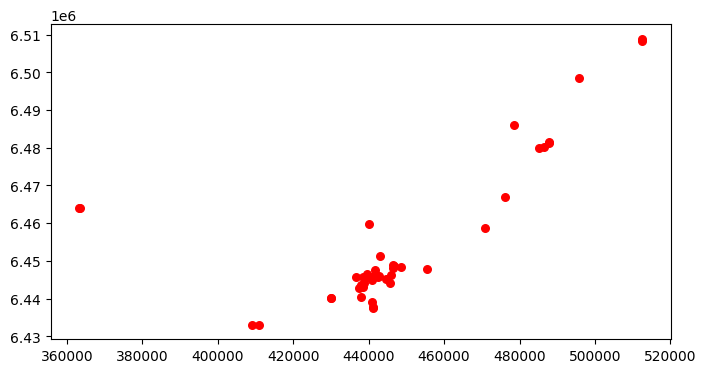

In [102]:
tilfluktsrom_100.plot(figsize=(8,8), color="red", markersize=30)


## Romlig filtrering: Tilfluktsrom med høy kapasitet nær vegnett
Tilgjengelighet er en kritisk faktor i evakueringssituasjoner. Her undersøker jeg hvor mange av de store tilfluktsrommene (over 100 plasser) som ligger nær viktige transportårer. Jeg lager en buffersone på 150 meter rundt vegnettet og finner tilfluktsrom som ligger innenfor denne sonen.

## Romlig filtrering med spatial index (effektiv metode for store datasett)

Vegnett-datasettet inneholder over 118 000 linjeobjekter, noe som gjør tradisjonelle
GIS-operasjoner som `unary_union` og store bufferoperasjoner svært tunge for Google
Colab. For å unngå at notebooken krasjer bruker jeg en mer effektiv metode basert på
spatial indexing.

I stedet for å buffre hele vegnettet lager vi en romlig indeks (R-tree) og søker
kun etter vegsegmenter som ligger i nærheten av hvert tilfluktsrom. Deretter lager vi en liten buffer rundt disse segmentene og sjekker om tilfluktsrommet ligger innenfor bufferen. Dette gir samme faglige resultat, men er langt raskere og mer ressursvennlig.

Dette ble gjort siden colab kræsjet når det prøvde behandle datasettet.

In [103]:
from shapely.geometry import Point
from shapely.ops import unary_union

# 1. Reprojiser begge datasett til meter-basert CRS
vegnett = vegnett.to_crs(epsg=25832)
tilfluktsrom_100 = tilfluktsrom_100.to_crs(epsg=25832)

# 2. Lag spatial index for vegnett
veg_sindex = vegnett.sindex

# 3. Buffer-avstand
buffer_dist = 150  # meter

# 4. Liste for treff
treff = []

# 5. Gå gjennom hvert tilfluktsrom
for idx, row in tilfluktsrom_100.iterrows():
    punkt = row.geometry

    # Finn vegsegmenter i nærheten (bounding box)
    possible_matches_index = list(veg_sindex.intersection(punkt.buffer(buffer_dist).bounds))
    possible_matches = vegnett.iloc[possible_matches_index]

    # Buffer kun disse segmentene
    local_buffer = possible_matches.buffer(buffer_dist)

    # Sjekk om punktet ligger i bufferen
    if local_buffer.intersects(punkt).any():
        treff.append(idx)

# 6. Lag GeoDataFrame med treff
tilfluktsrom_100_nar_veg = tilfluktsrom_100.loc[treff]

print("Antall store tilfluktsrom nær vegnett:", len(tilfluktsrom_100_nar_veg))
tilfluktsrom_100_nar_veg.head()


Antall store tilfluktsrom nær vegnett: 46


,gml_id,lokalId,navnerom,versjonId,datauttaksdato,opphav,romnr,plasser,adresse,geometry
0,ida9f2c8a6-0c15-4de7-b48c-463b5f72d369,eeafdd2e-6876-46b9-bc03-1c6c66d51d90,https://data.geonorge.no/sosi/samfunnssikkerhe...,20191001,2026-03-12T01:40:03,Direktoratet for samfunnssikkerhet og beredskap,1688,136,BANEHEIVEIEN,POINT (440100.586 6445767.752)
1,idbbd67a0e-c183-469b-ae3d-c3c482d7309b,e5cb6a5c-1573-4fe6-8233-12ae7fb62d76,https://data.geonorge.no/sosi/samfunnssikkerhe...,20191001,2026-03-12T01:40:03,Direktoratet for samfunnssikkerhet og beredskap,1707,195,BYDALSVEIEN 19,POINT (436546.844 6445699.758)
3,id58efe90c-adc2-4554-8e43-0e69426855e5,3b3f7d28-2e3a-4e94-90be-29302ad62da1,https://data.geonorge.no/sosi/samfunnssikkerhe...,20191001,2026-03-12T01:40:03,Direktoratet for samfunnssikkerhet og beredskap,1755,235,GROSTØLVEIEN 4 E,POINT (443105.631 6451405.729)
4,iddd7f7ff3-e068-4a9d-a2ea-14d89e6350d2,0a7547bf-9565-4bca-806e-5b0a8718a36a,https://data.geonorge.no/sosi/samfunnssikkerhe...,20191001,2026-03-12T01:40:03,Direktoratet for samfunnssikkerhet og beredskap,1756,500,GRÅGÅSVEIEN 43,POINT (437355.394 6442727.193)
5,id0a5eb0d1-354f-4efa-85ea-31e94996a192,d4a8b739-edad-41d7-8392-e3ccf4b1492c,https://data.geonorge.no/sosi/samfunnssikkerhe...,20191001,2026-03-12T01:40:03,Direktoratet for samfunnssikkerhet og beredskap,1776,170,RAVNEDALSVEIEN 34,POINT (439556.726 6446438.553)


### Visualisering av store tilfluktsrom nær vegnett
Her visualiserer vi tilfluktsrom med mer enn 100 plasser som ligger innenfor 150 meter fra vegnett. Dette gir et visuelt inntrykk av hvilke store tilfluktsrom som er lett tilgjengelige i en evakueringssituasjon.


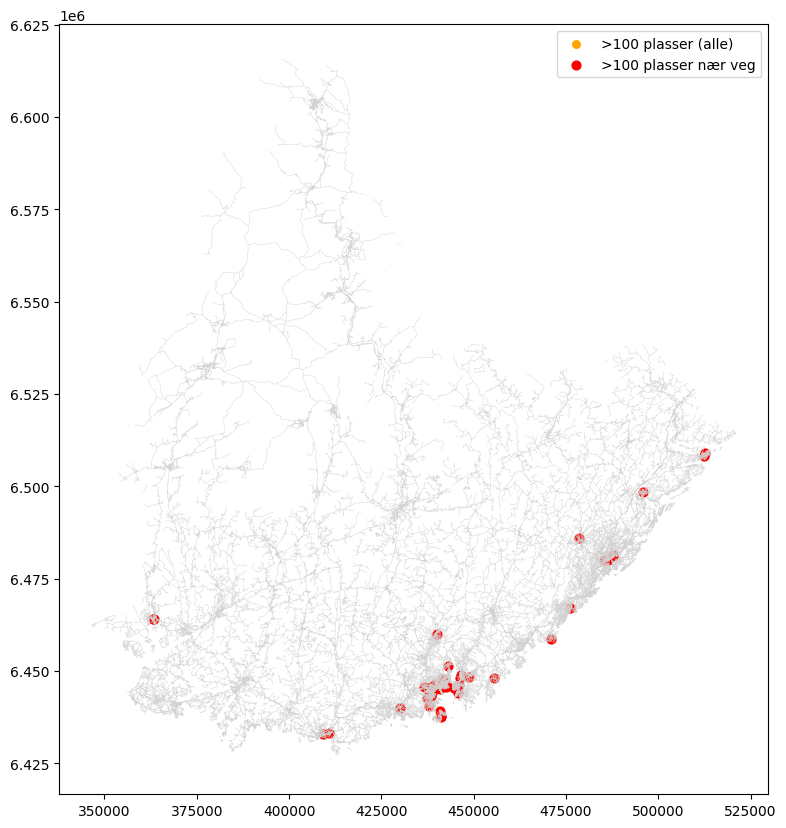

In [104]:
ax = vegnett.plot(figsize=(10, 10), color="lightgrey", linewidth=0.3)
tilfluktsrom_100.plot(ax=ax, color="orange", markersize=30, label=">100 plasser (alle)")
tilfluktsrom_100_nar_veg.plot(ax=ax, color="red", markersize=40, label=">100 plasser nær veg")
ax.legend()

### Resultater
For å forstå hvor godt tilgjengelige de store tilfluktsrommene er, ser jeg på
hvor mange av dem som ligger nær vegnett, og hvor stor andel dette utgjør.

In [105]:
totale_store = len(tilfluktsrom_100)
nare_store = len(tilfluktsrom_100_nar_veg)
andel = (nare_store / totale_store * 100) if totale_store > 0 else 0

print("Totalt antall tilfluktsrom >100 plasser:", totale_store)
print("Antall tilfluktsrom >100 plasser nær vegnett:", nare_store)
print(f"Andel store tilfluktsrom nær vegnett: {andel:.1f}%")


Totalt antall tilfluktsrom >100 plasser: 46
Antall tilfluktsrom >100 plasser nær vegnett: 46
Andel store tilfluktsrom nær vegnett: 100.0%


### Funn
Analysen viser at alle de 46 tilfluktsrommene med mer enn 100 plasser ligger innenfor 150 meter fra vegnett. Resultatet indikerer at de største tilfluktsrommene i Agder er svært godt plassert med tanke på tilgjengelighet i en evakueringssituasjon.

At alle store tilfluktsrom ligger nær vegnett kan tyde på at lokaliseringen er
planlagt med tanke på rask adkomst, både for befolkningen og for nødetater. Dette er positivt for sivil beredskap, ettersom store tilfluktsrom ofte fungerer som primære samlingspunkter ved større hendelser.

Videre analyser fokusere på mindre tilfluktsrom, geografiske hull i dekningen eller sammenhengen mellom befolkningstetthet og tilfluktsromskapasitet.

## 1. Installasjon av geografiske analyseverktøy
Siden Google Colab er et generelt miljø, må vi installere GDAL (Geospatial Data Abstraction Library) for å kunne utføre avanserte rasteranalyser. Dette biblioteket er industristandarden for prosessering av høydedata og konvertering mellom raster- og vektorformater.

In [106]:
!apt-get update
!apt-get install gdal-bin python3-gdal

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
gdal-bin is already the newest version (3.8.4+dfsg-1~jammy0).
python3-gdal is already the newe

In [107]:
import numpy as np
from osgeo import gdal, osr

# Definer størrelsen på testbildet (f.eks. 100x100 piksler)
width, height = 100, 100

# Lag et kunstig terreng med en "bakke" (verdier fra 0 til 500 meter)
y, x = np.indices((height, width))
terrain = (x * 2 + y * 3).astype(np.float32)

# Opprett GeoTIFF-filen
driver = gdal.GetDriverByName('GTiff')
ds = driver.Create('test_dem.tif', width, height, 1, gdal.GDT_Float32)

# Sett et fiktivt koordinatsystem (viktig for at GDAL skal fungere)
srs = osr.SpatialReference()
srs.ImportFromEPSG(25833) # UTM sone 33N (Norge)
ds.SetProjection(srs.ExportToWkt())
ds.SetGeoTransform([400000, 10, 0, 6400000, 0, -10]) # Posisjon og pikselstørrelse

# Skriv dataene til filen
band = ds.GetRasterBand(1)
band.WriteArray(terrain)
band.FlushCache()
ds = None # Lukker filen ordentlig

print("Suksess: En ny 'test_dem.tif' er opprettet i arbeidsmappen din.")

Suksess: En ny 'test_dem.tif' er opprettet i arbeidsmappen din.


## 2. Generering av helningskart og evakueringssoner
I denne prosessen tar vi den digitale høydemodellen (DEM) og utfører tre operasjoner:
1. Beregner helning i grader for å identifisere bratthet.
2. Filtrerer ut alle områder med over 30 graders helning, da disse anses som rasfarlige og ufremkommelige.
3. Konverterer disse kritiske sonene til vektorformat (GeoJSON) slik at de kan brukes i kombinasjon med kart over veinett og befolkning.

In [108]:
# 1. Lag helningskart (Slope)
!gdaldem slope /content/drive/MyDrive/IS218-Datasett/dtm10_6400_1_10m_z33.tif slope.tif -of GTiff -b 1 -s 1.0

# 2. Lag maske for kritiske områder (> 30 grader)
!gdal_calc.py -A slope.tif --calc="A>=30" --outfile=slope_mask.tif --NoDataValue=0 --overwrite

# 3. Konverter til vektor (Polygonize)
!gdal_polygonize.py slope_mask.tif -f "GeoJSON" bratte_omrader.geojson

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [109]:
import geopandas as gpd

# Les inn den nyskapte fila
gdf = gpd.read_file('bratte_omrader.geojson')

# Fortell systemet at dette er UTM33 (EPSG:25833)
gdf.crs = "EPSG:25833"

# Konverter til grader (EPSG:4326)
gdf_web = gdf.to_crs("EPSG:4326")

# Klargjøre endelig GeoJSON-fil med korrekte koordinater for bruk i kartmodulen.
gdf_web.to_file('bratte_omrader_final.geojson', driver='GeoJSON')

print("Suksess! 'bratte_omrader_final.geojson' er nå lagret med korrekt koordinatsystem.")

Suksess! 'bratte_omrader_final.geojson' er nå lagret med korrekt koordinatsystem.


## 3. Terrengvisualisering og datavalidering
For å gi en intuitiv forståelse av landskapet genererer vi to hillshade-varianter med ulike lysvinkler. Dette fremhever topografien for beslutningstakere. Vi avslutter med en matematisk kontroll av dataene for å verifisere at helningsverdiene ligger innenfor den gyldige rammen på 0-90 grader.

In [110]:
# Generer to varianter av Hillshade
!gdaldem hillshade test_dem.tif hillshade_standard.tif -az 315 -alt 45
!gdaldem hillshade test_dem.tif hillshade_lav_sol.tif -az 315 -alt 20

# Validering av dataene (Unit Test)
from osgeo import gdal
import numpy as np

ds = gdal.Open('slope.tif')
slope_data = ds.GetRasterBand(1).ReadAsArray()
valid_data = slope_data[slope_data != -9999] # Antar -9999 som NoData

print(f"Kontrollmåling - Maks helning: {np.max(valid_data):.2f} grader")
if np.max(valid_data) <= 90:
    print("STATUS: Data validert og klare for overlevering til vektoranalyse.")
else:
    print("STATUS: Feil oppdaget i helningsberegning.")

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
Kontrollmåling - Maks helning: 77.45 grader
STATUS: Data validert og klare for overlevering til vektoranalyse.


Vektoranalyser – beredskap og dekning

I denne delen analyserer jeg beredskapen i Agder ved hjelp av vektordata. Målet er å undersøke hvor godt tilfluktsrom er dekket av brannstasjoner.

Jeg bruker buffer for å modellere dekning, og overlay-operasjoner for å finne hvilke områder som er dekket og hvilke som mangler dekning.

###1. Bufferanalyse av brannstasjoner

Her oppretter jeg en buffersone på 500 meter rundt hver brannstasjon. Dette gir en enkel modell av hvor rask tilgang man har til beredskapstjenester.

In [111]:
agder = fylker[fylker["fylkesnavn"] == "Agder"].copy()
agder

,objtype,samiskForvaltningsområde,identifikasjon.Identifikasjon.lokalId,identifikasjon.Identifikasjon.navnerom,identifikasjon.Identifikasjon.versjonId,datafangstdato,oppdateringsdato,datauttaksdato,opphav,fylkesnummer,administrativenhetnavn,fylkesnavn,gyldigFra,gyldigTil,geometry
7,Fylke,False,3a65f9e4-23d5-4c05-b188-8f4ea8463f8b,https://data.geonorge.no/sosi/inndelinger/innd...,48,None,2025-11-11 11:08:37+00:00,2025-12-10 15:39:43+01:00,None,42,"[{'navn': 'Agder', 'rekkefolge': '0', 'sprak':...",Agder,2025-11-11,None,"MULTIPOLYGON (((168245.71 6487232.71, 170423.3..."


In [112]:
# Sørger for samme koordinatsystem
agder = agder.to_crs(epsg=25833)
brannstasjoner = brannstasjoner.to_crs(epsg=25833)
tilfluktsrom = tilfluktsrom.to_crs(epsg=25833)

# Lager 500 meters buffer rundt brannstasjonene
brann_buffer = brannstasjoner.copy()
brann_buffer["geometry"] = brann_buffer.buffer(2000)

brann_buffer.head()

,gml_id,opphav,brannstasjon,brannvesen,stasjonstype,kasernert,geometry
0,idbb7d5177-8c1e-4c9f-909f-3699b65732eb,DSB,Kvinlog,Brannvesenet Sør IKS,L,IK,"POLYGON ((32941.003 6515095.984, 32931.373 651..."
1,id6904f551-1dab-4e07-a803-2c278c6c094a,DSB,Vegårshei,Østre Agder Brannvesen,L,IK,"POLYGON ((147442 6528311.998, 147432.37 652811..."
2,idbb63ecff-5788-4183-b395-5af442214e1c,DSB,Spangereid,Brannvesenet Sør IKS,L,IK,"POLYGON ((37349.003 6460005.986, 37339.372 645..."
3,id3be8df5d-295b-45af-8a02-3656f29f2fca,DSB,Valle,Setesdal Brannvesen IKS,L,IK,"POLYGON ((76660.002 6588581.991, 76650.371 658..."
4,id3d9cf91b-ee91-42a3-b504-c62c7ee88b56,DSB,Risør,Østre Agder Brannvesen,L,DA,"POLYGON ((166973 6523168.999, 166963.37 652297..."


###2. Analyse av tilfluktsrom innenfor dekningsområder

Her undersøker jeg hvilke tilfluktsrom som ligger innenfor buffersonene til brannstasjonene. Dette gir en indikasjon på hvor godt disse er dekket av beredskap.

In [113]:
tilflukt_i_buffer = gpd.overlay(tilfluktsrom, brann_buffer, how="intersection")

len(tilflukt_i_buffer)

34

###3. Identifisering av områder uten dekning

Her finner jeg områder som ikke er dekket av buffersonene. Dette kan indikere områder med potensielt svak beredskap.

In [114]:
uten_dekning = gpd.overlay(agder, brann_buffer, how="difference")

uten_dekning.head()

# Identify which brann_buffer geometries contain any tilfluktsrom
brann_med_tilflukt = brann_buffer[brann_buffer.intersects(tilfluktsrom.unary_union)]

# Identify which brann_buffer geometries do NOT contain any tilfluktsrom
brann_uten_tilflukt = brann_buffer[~brann_buffer.intersects(tilfluktsrom.unary_union)]

/tmp/ipykernel_35768/61322804.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  brann_med_tilflukt = brann_buffer[brann_buffer.intersects(tilfluktsrom.unary_union)]
/tmp/ipykernel_35768/61322804.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  brann_uten_tilflukt = brann_buffer[~brann_buffer.intersects(tilfluktsrom.unary_union)]


###4. Visualisering av beredskapsdekning

Til slutt visualiserer jeg resultatene for å få en bedre oversikt over hvordan dekningen faktisk ser ut geografisk.

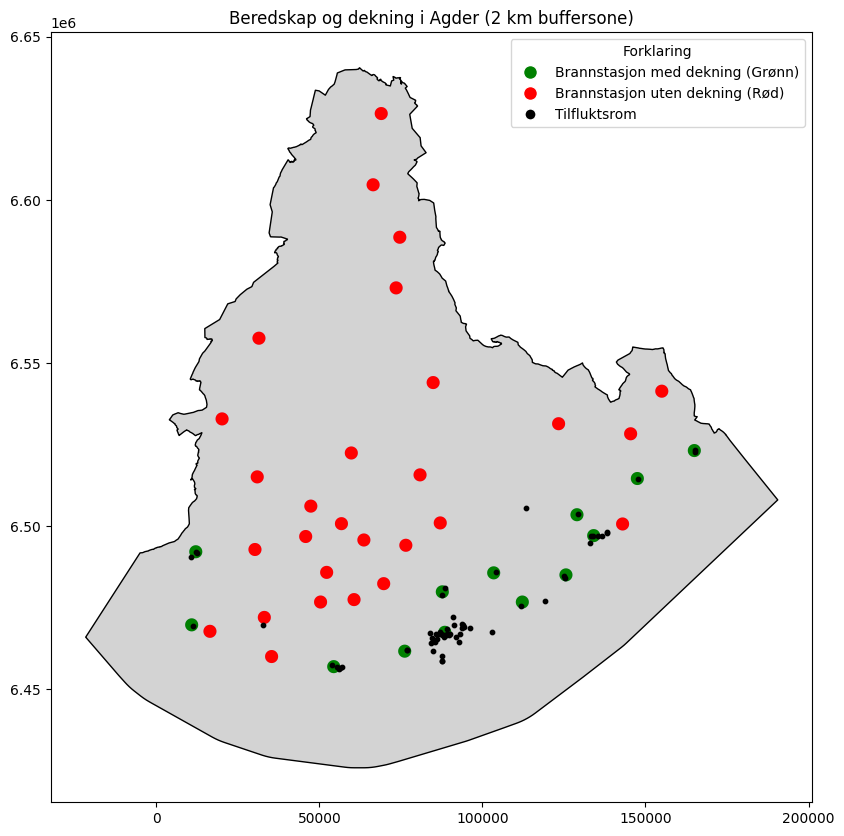

In [115]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

# Bakgrunn
agder.plot(ax=ax, color="lightgrey", edgecolor="black")

# Buffere
brann_buffer.plot(ax=ax, alpha=0.15, color="blue")

# God dekning (GRØNN)
brann_med_tilflukt.plot(
    ax=ax,
    color="green",
    markersize=60,
)

# Dårlig dekning (RØD)
brann_uten_tilflukt.plot(
    ax=ax,
    color="red",
    markersize=60,
)

# Tilfluktsrom
tilfluktsrom.plot(
    ax=ax,
    color="black",
    markersize=10,
    label="Tilfluktsrom"
)


from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='Brannstasjon med dekning (Grønn)',
           markerfacecolor='green', markersize=10),

    Line2D([0], [0], marker='o', color='w',
           label='Brannstasjon uten dekning (Rød)',
           markerfacecolor='red', markersize=10),

    Line2D([0], [0], marker='o', color='w',
           label='Tilfluktsrom',
           markerfacecolor='black', markersize=8)
]

ax.legend(handles=legend_elements, title="Forklaring", loc="upper right")

# Tittel
plt.title("Beredskap og dekning i Agder (2 km buffersone)")

plt.show()

###5. Funn

Resultatene viser at flere tilfluktsrom ligger innenfor rimelig avstand til brannstasjoner, noe som tyder på god dekning i deler av området.

Samtidig, i litt mer landligere strøk, finnes det områder som ikke dekkes av buffersonene, noe som kan indikere svakere beredskap. Dette viser hvordan GIS-analyser kan brukes til å identifisere potensielle forbedringsområder innen samfunnssikkerhet.